In [1]:
import pandas as pd
df_A = pd.DataFrame({
        "Temperature":[20,30,40,50,60]
        },
    index = ['Day1','Day2','Day3','Day4','Day5']
)

df_B = pd.DataFrame({
        "Humidity":[120,230,240,450,160]
        },
    index = ['Day1','Day2','Day3','Day6','Day7']
)

joined_df = df_A.join(df_B,how="outer")
print(joined_df)

      Temperature  Humidity
Day1         20.0     120.0
Day2         30.0     230.0
Day3         40.0     240.0
Day4         50.0       NaN
Day5         60.0       NaN
Day6          NaN     450.0
Day7          NaN     160.0


In [2]:
wide_df = pd.DataFrame({
    "Name":["Hari","Shyam"],
    'Science':[30,50],
    'Math':[29,40],
    'English':[40,10]
})
wide_df

,Name,Science,Math,English
0,Hari,30,29,40
1,Shyam,50,40,10


In [3]:
long_df = pd.melt(
    frame=wide_df,
    id_vars='Name',
    var_name="Subject",
    value_name="Marks"
)
print(long_df)

    Name  Subject  Marks
0   Hari  Science     30
1  Shyam  Science     50
2   Hari     Math     29
3  Shyam     Math     40
4   Hari  English     40
5  Shyam  English     10


In [4]:
sort_df = long_df.pivot(
    columns='Subject',
    values='Marks',
    index='Name'
)
sort_df

Subject,English,Math,Science
Name,,,
Hari,40,29,30
Shyam,10,40,50


In [5]:
stacked_df = long_df.stack()
print(stacked_df)

0  Name          Hari
   Subject    Science
   Marks           30
1  Name         Shyam
   Subject    Science
   Marks           50
2  Name          Hari
   Subject       Math
   Marks           29
3  Name         Shyam
   Subject       Math
   Marks           40
4  Name          Hari
   Subject    English
   Marks           40
5  Name         Shyam
   Subject    English
   Marks           10
dtype: object


In [6]:
unstacked_df = stacked_df.unstack()
print(unstacked_df)

    Name  Subject Marks
0   Hari  Science    30
1  Shyam  Science    50
2   Hari     Math    29
3  Shyam     Math    40
4   Hari  English    40
5  Shyam  English    10


In [7]:
pivot_table_df = pd.pivot_table(
    data = long_df,
    index='Name',
    columns='Subject',
    values='Marks',
    aggfunc ='mean'
)
pivot_table_df

Subject,English,Math,Science
Name,,,
Hari,40.0,29.0,30.0
Shyam,10.0,40.0,50.0


In [8]:
import pandas as pd
df = pd.read_csv('test.csv')
df.head()

,Roll,Name,Age,Address
0,1,'Ram',22.0,Dharan
1,2,'Shyam',NaN,'Biratnagar'
2,3,'hari',33.0,'chitwan'
3,4,NaN,32.0,'Kathmandu'
4,5,'Gopal',NaN,'Butwal'


In [9]:
#Drop the rows with missing values.
df_1 = df.dropna()
df_1

,Roll,Name,Age,Address
0,1,'Ram',22.0,Dharan
2,3,'hari',33.0,'chitwan'


In [10]:
#Fill missing values in age column with the mean.
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.head()

,Roll,Name,Age,Address
0,1,'Ram',22.0,Dharan
1,2,'Shyam',29.0,'Biratnagar'
2,3,'hari',33.0,'chitwan'
3,4,NaN,32.0,'Kathmandu'
4,5,'Gopal',29.0,'Butwal'


In [11]:
#Fill missing values in name column with unknown
df['Name'] = df['Name'].fillna('Unknown')
df


,Roll,Name,Age,Address
0,1,'Ram',22.0,Dharan
1,2,'Shyam',29.0,'Biratnagar'
2,3,'hari',33.0,'chitwan'
3,4,Unknown,32.0,'Kathmandu'
4,5,'Gopal',29.0,'Butwal'


In [12]:
df.to_csv('final.csv',index=False)

In [13]:
import pandas as pd
df = pd.DataFrame({
    'EID':[101,102,103,104],
    'Name':['Ram','Shyam','Hari','Sita'],
    'Level':['Junior','Senior','Mid','Junior']
})
df.dtypes

EID       int64
Name     object
Level    object
dtype: object

In [14]:
df['Level'] = df['Level'].astype('category')
df.dtypes

EID         int64
Name       object
Level    category
dtype: object

In [15]:
df['Level'] = df['Level'].cat.rename_categories({
    "Junior":'Jr',
    "Senior":"Sr"
})
df.head()

,EID,Name,Level
0,101,Ram,Jr
1,102,Shyam,Sr
2,103,Hari,Mid
3,104,Sita,Jr


In [16]:
df['Level_code'] = df['Level'].cat.codes
df.head()

,EID,Name,Level,Level_code
0,101,Ram,Jr,0
1,102,Shyam,Sr,2
2,103,Hari,Mid,1
3,104,Sita,Jr,0


In [17]:
encoded = pd.get_dummies(df['Level'],prefix='Lev')
df = pd.concat(objs=[df,encoded],axis=1)
df

,EID,Name,Level,Level_code,Lev_Jr,Lev_Mid,Lev_Sr
0,101,Ram,Jr,0,True,False,False
1,102,Shyam,Sr,2,False,False,True
2,103,Hari,Mid,1,False,True,False
3,104,Sita,Jr,0,True,False,False


In [47]:
import pandas as pd
df_time =pd.DataFrame({
    'Date' : ['2025-01-11','2025-01-12','2025-01-13','2025-01-14'],
    'Sales':[101,104,105,102]
})
df_time

,Date,Sales
0,2025-01-11,101
1,2025-01-12,104
2,2025-01-13,105
3,2025-01-14,102


In [48]:
df_time['Date'] = pd.to_datetime(df_time['Date'])
df_time = df_time.set_index('Date')
print(df_time)

            Sales
Date             
2025-01-11    101
2025-01-12    104
2025-01-13    105
2025-01-14    102


In [62]:
# df_time['Year'] = df_time.index.year
# df_time['Month'] = df_time.index.month
# df_time['Day'] = df_time.index.day
# df_time['DayName'] = df_time.index.day_name()

# print(df_time)

df_time.index.day_name()


Index(['Saturday', 'Sunday', 'Monday', 'Tuesday'], dtype='object', name='Date')

In [ ]:
#feature transfromation
#Log transfromation

import numpy as np
x = np.array([100,200,300,500,6000])
X_transformed = np.log1p(x)
print(X_transformed)


[8.6996814  4.61512052 5.30330491 5.70711026 6.2166061 ]


(array([4., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([ 100.,  690., 1280., 1870., 2460., 3050., 3640., 4230., 4820.,
        5410., 6000.]),
 <BarContainer object of 10 artists>)

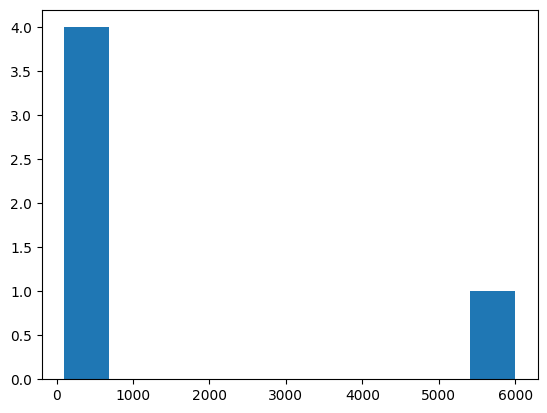

In [ ]:
import matplotlib.pyplot as plt 
plt.hist(x)

(array([1., 1., 1., 1., 0., 0., 0., 0., 0., 1.]),
 array([4.61512052, 5.02357661, 5.43203269, 5.84048878, 6.24894487,
        6.65740096, 7.06585705, 7.47431314, 7.88276922, 8.29122531,
        8.6996814 ]),
 <BarContainer object of 10 artists>)

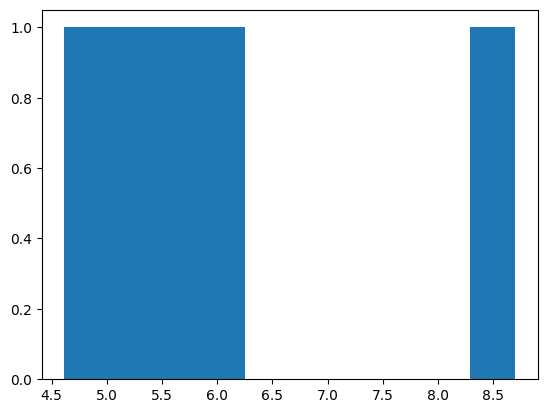

In [ ]:
plt.hist(X_transformed)

In [ ]:
#Power transfromation

from sklearn.preprocessing import PowerTransformer
import numpy as np
x = np.array([100,200,300,500,6000])
pt = PowerTransformer(method='yeo-johnson')
pt.fit_transform()

ModuleNotFoundError: No module named 'sklearn'